In [16]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [17]:
# Creating of the abstract class
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


In [18]:
# The node class
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


In [19]:
# Helper Function
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


In [20]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # :
        # Return True if state is equal to the goal state.
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        # 2. For each action in MOVES:()
        #       a. Compute the neighbour cell.

        #       b. Check that it is in bounds.

        #       c. Check that it is free.

        #       d. If valid, add the action name to legal_actions.
        for action, (dr, dc) in MOVES.items():
            row, col = state
            new_row = row + dr
            new_col = col + dc
            new_state = (new_row, new_col)

            if self.in_bounds(new_state) and self.is_free(new_state):
                legal_actions.append(action)
        # 3. Return legal_actions.
        return legal_actions
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # 3:
        # Return the next state after applying action to state.
        #
        row, col = state
        # Hint:
        dr, dc = MOVES[action]
        return (row + dr, col + dc)
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        #:
        # In this lab, each valid move has a cost of 1.
        return 1.0
        # Return 1.
        raise NotImplementedError("Complete GridProblem.action_cost")


In [21]:
# 5.1 Self check for GridProblem

test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")


GridProblem self-check passed.


In [22]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)


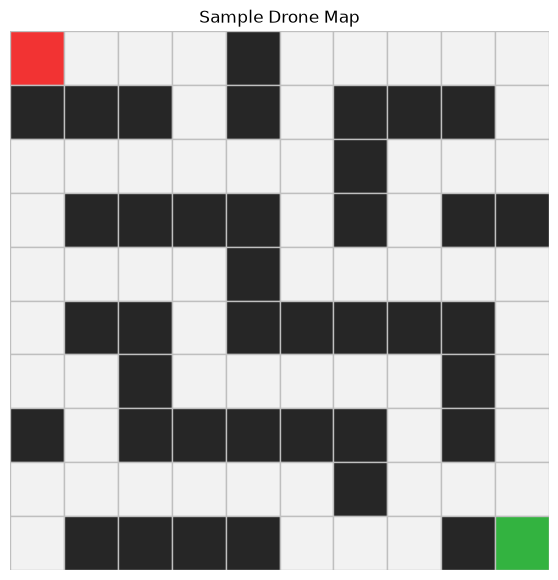

In [23]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()


plot_path(sample_grid, start, goal, title="Sample Drone Map")


In [24]:
class SearchAlgorithm(ABC):
    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(  # ← Use Node class, not node
                state=s_prime, parent=node, action=action, path_cost=cost
            )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


In [25]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        nodes_expanded = 0
        max_frontier_size = 1
        node = Node(problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="Success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=1,
            )

        frontier = deque([node])
        reached = {node.state}

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            # FIXED: Use self.expand instead of node.expand
            for child in self.expand(problem, node):
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="Success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="Failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [26]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # 7:
        node = Node(problem.initial_state())
        nodes_expanded = 0
        max_frontier_size = 1

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                solution=node,
                status="Success",
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=1,
            )

        frontier = [node]
        reached = {node.state}

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            for child in reversed(list(self.expand(problem, node))):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="Success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="Failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [27]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        if problem.is_goal(node.state):
            return node, "success"

        if node.depth >= limit:
            return None, "cutoff"

        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):  # using global helper
                continue

            new_stack_size = current_stack_size + 1
            if new_stack_size > metrics["max_stack_size"]:
                metrics["max_stack_size"] = new_stack_size

            result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=new_stack_size,
            )

            if status == "success":
                return result, "success"

            if status == "cutoff":
                cutoff_occurred = True

        # After all children
        if cutoff_occurred:
            return None, "cutoff"
        else:
            return None, "failure"

In [28]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log = []
        total_nodes_expanded = 0
        max_stack_size = 0

        for limit in range(0, max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)

            iteration_log.append(
                {
                    "limit": limit,
                    "nodes_expanded": result.nodes_expanded,
                    "status": result.status,
                }
            )

            total_nodes_expanded += result.nodes_expanded
            if result.max_frontier_size > max_stack_size:
                max_stack_size = result.max_frontier_size

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )

            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )

        # All cutoffs
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log,
        )

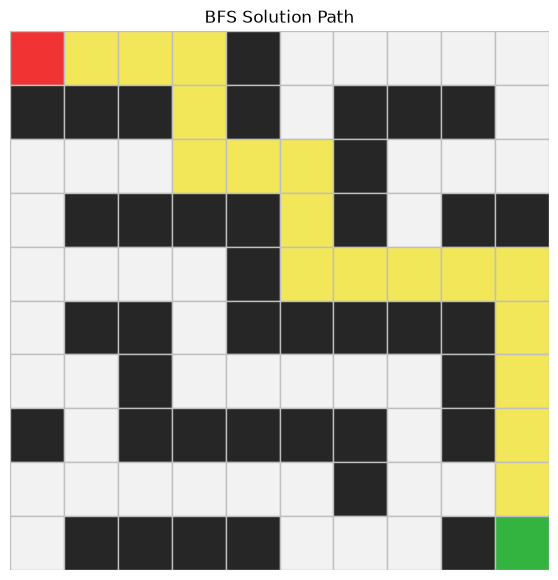

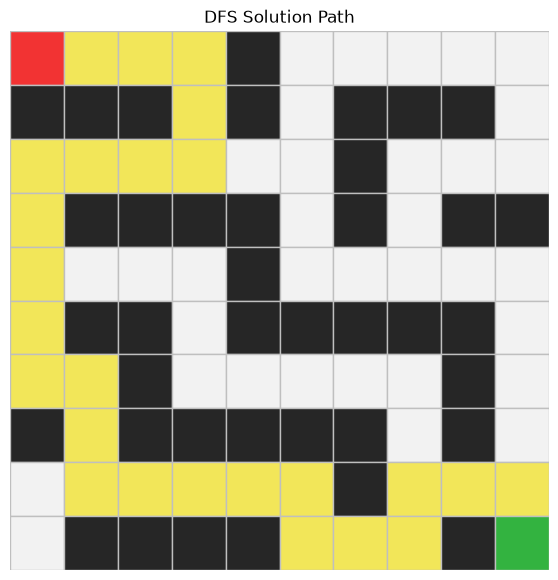

In [29]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)


bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

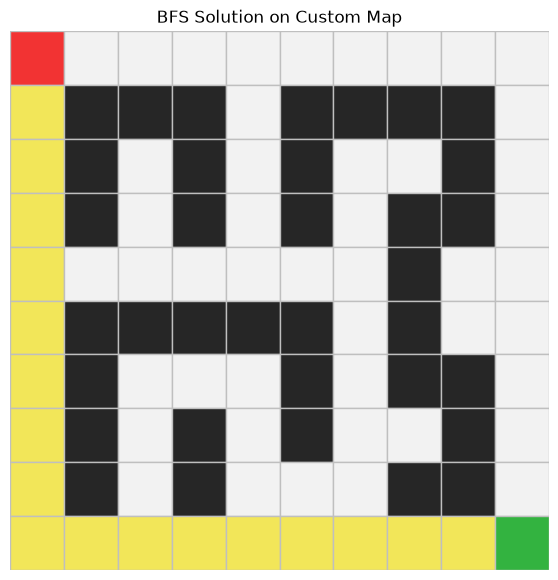

In [30]:
#10: Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 1, 0, 1, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (9, 9)

# Create the problem
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

# Test your algorithms on the custom map
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

show_results(custom_results_1)

# Visualize the solution
bfs_result = custom_results_1[0]
plot_path(
    custom_grid_1, 
    custom_start_1, 
    custom_goal_1, 
    path=bfs_result.path, 
    title="BFS Solution on Custom Map"
)

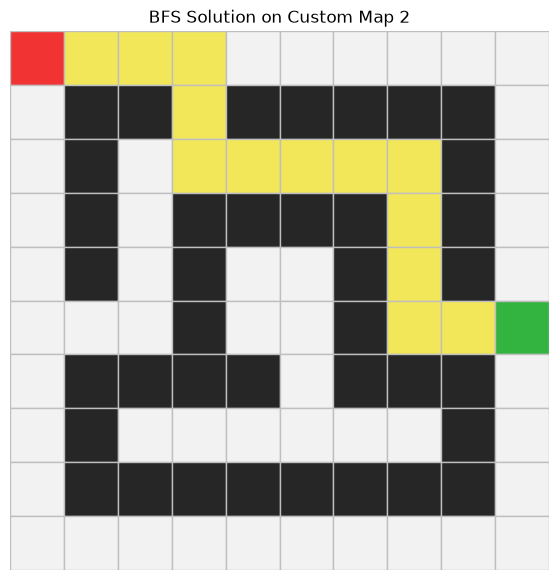

In [31]:
# 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (5, 9)

# Create the problem
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

# Run all algorithms on the second custom map
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]

show_results(custom_results_2)

# Visualize BFS solution
bfs_result2 = custom_results_2[0]
plot_path(
    custom_grid_2, 
    custom_start_2, 
    custom_goal_2, 
    path=bfs_result2.path, 
    title="BFS Solution on Custom Map 2"
)

**What is a state in this lab?**
 A state is a position on the grid represented as a tuple (row,column).

**What is an action?**
An action is a possible move from the current state to an adjacent state.

**What does the result function?**
The result function returns the new state that results from applying the given action to the current state.

**Why is it useful to separate the problem definition from the search algorithm?**
Separating them allows search algorithms to be reused. If this is not done, a search algorithm would be written making them duplicates.

**15.2 BFS**
**1. Why does BFS use a FIFO queue?**
A FIFO queue is used to make sure the longest node in the queue is expanded first. BFS explores node in the order they are discovered. This makes FIFO Queue the best for storing in the frontier.

**Why does BFS find the shortest path in terms of number of steps on the unweightd grid?**
Because it explores all depth step by step, like first depth then to second depth and so on. The first time the goal is found, it must be at the smallest possible depth.

**What role does the reached set play in BFS?**
The reached set prevents revisiting the same state multiple times, avoiding redundant work and infinite loops in graphs with cycles.

**15. 3 DFS**
**Why does DFS use a stack?**
A stack(LIFO) implements going as deep as possible along one branch before backtracking.

**Is DFS guaranteed to find the shortest path? Explain**
No. DFS can find a very long path first if it goes deep down a wrong branch.

**Under what conditions can DFS use less memory than BFS**
When the state space has a high branching factor but solutions are found deep in the tree. (DFS only stores the current path + frontier along one branch)

**Under what conditions can DFS perform badly?**
DFS can perform badly when there are long incorrect paths. It may spend a lot of time exploring branches that are not productive before reaching the goal.

**15.4 DLS**
**What happens when the depth limit is too small?**
The search may fail to reach the goal even if a solution exists.

**What is the meaning of "cutoff"**
Cutoff means the search reached the depth limit without finding the goal and without exploring all possible paths at that depth.

**How is DLS different from ordinary DFS?**
DLS imposes a maximum depth limit to prevent infinite descent, making it safer in large or infinte spaces

**Why do we use path-cycle checking in DLS?**
To avoid revisiting states along the current path, preventing infinite loops even within the depth limit.


**15.5 IDS**
**Why does IDS repeat DLS with increasing limits?**
To combine the completeness and optimality of BFS with the low memory usage of DFS by gradually increasing the depth limit.

**Why can IDS be complete even though DLS with a small limit is not?**
Because the depth limit is increased until it is large enough to reach the solution (assuming finite depth).

**Why does IDS use less memory than BFS?**
Like DFS, it only needs to store the current path (O(d) space), not all nodes at the current level (O(b^d) for BFS).

**What is the cost of repeatedly searching from the root?**
Redundant work on the upper levels of the tree. However, this overhead is usually small because the number of nodes at shallow depths grows exponentially — most work happens at the deepest level.


**15.6**
**In a real drone application, what might make one route safer or more practical than another**
A route is safer if it avoids bad weather, obstacles, checks the total distance to use battery power efficiently. 

**Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain**
BFS is optimal for unweighted graphs and guarantees the shortest path in number of steps.

**Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.**
DLS. It enforces a maximum search depth, which is useful for real-time constraints or limied computational resources.

**What limitations does this grid model have compared with real drone navigation?**
In the grid problem, legal actions are just in four direction. Drones function in continuous 3D space and moves in any angles. Factors such as height/altitude, weather conditions, battery and obstacles. Grid model does not capture the real-world navigation.